In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv(r"C:\Users\ADMIN\Downloads\archive (2)\Salary_Data.csv")

In [4]:
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [5]:
df.isna().sum()

YearsExperience    0
Salary             0
dtype: int64

In [6]:
df.dtypes

YearsExperience    float64
Salary             float64
dtype: object

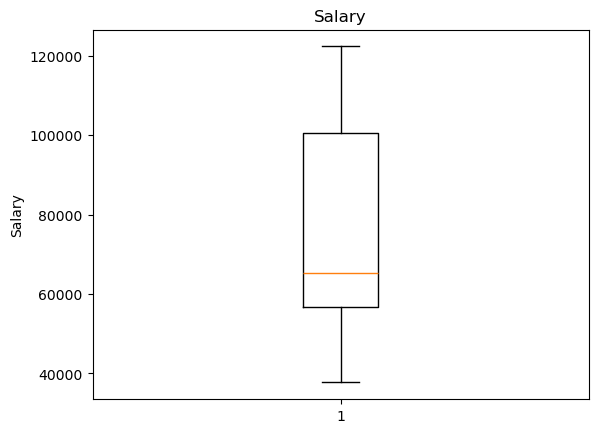

In [10]:
plt.boxplot(df['Salary'])

plt.title("Salary")
plt.ylabel("Salary")

plt.show()

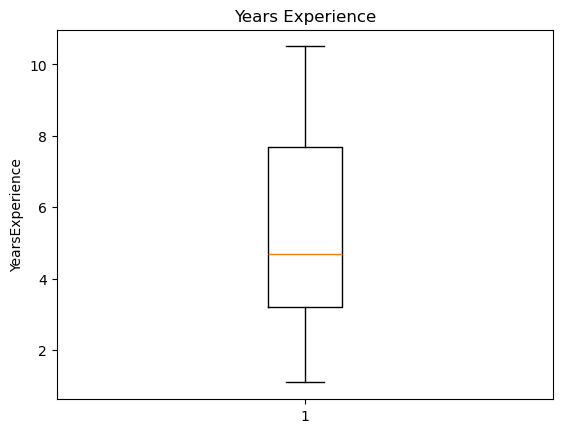

In [12]:
plt.boxplot(df['YearsExperience'])

plt.title("Years Experience")
plt.ylabel("YearsExperience")

plt.show()

In [9]:
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Salary'] < lower_bound) | (df['Salary'] > upper_bound)]

print(outliers)

Empty DataFrame
Columns: [YearsExperience, Salary]
Index: []


In [13]:
X = df[['YearsExperience']]
y = df['Salary']

In [15]:
print(X)

    YearsExperience
0               1.1
1               1.3
2               1.5
3               2.0
4               2.2
5               2.9
6               3.0
7               3.2
8               3.2
9               3.7
10              3.9
11              4.0
12              4.0
13              4.1
14              4.5
15              4.9
16              5.1
17              5.3
18              5.9
19              6.0
20              6.8
21              7.1
22              7.9
23              8.2
24              8.7
25              9.0
26              9.5
27              9.6
28             10.3
29             10.5


In [16]:
print(y)

0      39343.0
1      46205.0
2      37731.0
3      43525.0
4      39891.0
5      56642.0
6      60150.0
7      54445.0
8      64445.0
9      57189.0
10     63218.0
11     55794.0
12     56957.0
13     57081.0
14     61111.0
15     67938.0
16     66029.0
17     83088.0
18     81363.0
19     93940.0
20     91738.0
21     98273.0
22    101302.0
23    113812.0
24    109431.0
25    105582.0
26    116969.0
27    112635.0
28    122391.0
29    121872.0
Name: Salary, dtype: float64


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(24, 1)
(6, 1)
(24,)
(6,)


In [19]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [20]:
print(model)

LinearRegression()


In [21]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
y_pred = model.predict(X_test)
print(y_pred)

[115790.21011287  71498.27809463 102596.86866063  75267.80422384
  55477.79204548  60189.69970699]


In [25]:

import pandas as pd

comparison = pd.DataFrame({
    'Actual Salary': y_test,
    'Predicted Salary': y_pred
})

print(comparison)

    Actual Salary  Predicted Salary
27       112635.0     115790.210113
15        67938.0      71498.278095
23       113812.0     102596.868661
17        83088.0      75267.804224
8         64445.0      55477.792045
9         57189.0      60189.699707


In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))

print("MSE:", mean_squared_error(y_test, y_pred))

print("R2 Score:", r2_score(y_test, y_pred))

MAE: 6286.453830757742
MSE: 49830096.855908334
R2 Score: 0.9024461774180498


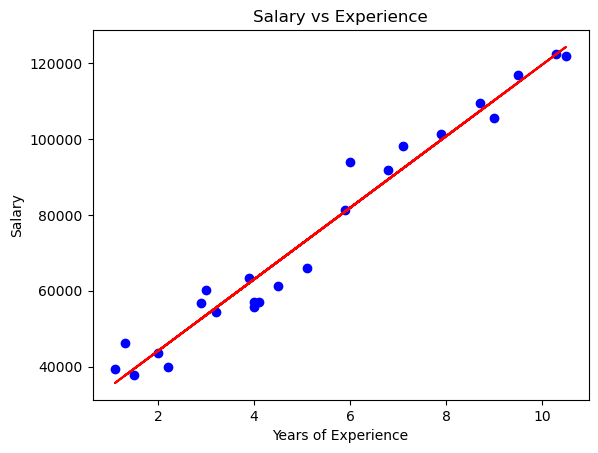

In [27]:
import matplotlib.pyplot as plt

plt.scatter(X_train, y_train, color='blue')

plt.plot(X_train, model.predict(X_train), color='red')

plt.xlabel("Years of Experience")
plt.ylabel("Salary")

plt.title("Salary vs Experience")

plt.show()